<h1 style="font-size:25px; font-weight:700; margin-bottom:10px;">
Personal Income and the Housing Market
</h1>
<div style="font-size:24px; font-family:'Times New Roman', Times, serif; margin-top:0px;">
<i>A vector autoregression analysis of disposable income and home prices, with Granger causality testing</i>
</div>

## Abstract

- Examines two questions about U.S. real disposable personal income and the S&P CoreLogic Case-Shiller U.S. National Home Price Index (monthly, 1987-2024)
- First, which characteristics of the income series itself contribute most to its own predictability: trend, seasonality, or both
- Second, whether a dynamic relationship exists between income and home prices, and in which direction
- Both series are tested for stationarity, differenced accordingly, then modeled jointly via a Vector Autoregression (VAR) with lag order selected by AIC
- Granger causality testing finds income predicts future home prices; home prices have a weaker but still significant reverse effect; residual diagnostics show the fitted VAR does not fully capture all serial dependence, so the relationship is read as a real, directional pattern rather than a fully specified forecasting model

## Introduction

- Disposable income and home prices are two of the most closely watched indicators of household financial health, and their joint dynamics matter for housing-market forecasting and policy
- This analysis has two aims: characterize what drives predictability within the income series itself, and establish whether income and home prices move together dynamically, and in which direction
- Both series are monthly, spanning January 1987 through late 2024
- Approach: stationarity testing (ADF, KPSS, Ljung-Box) on each series, differencing where needed, then a VAR model with Granger causality and residual diagnostics to characterize the income-price relationship

## Initialize Environment

In [1]:
# Libraries
library(tseries)   # Stationarity tests: adf.test, kpss.test
library(forecast)  # Time series decomposition & plotting: stl, autoplot
library(vars)       # Vector autoregression: VAR, VARselect, causality, serial.test

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



Loading required package: MASS



Loading required package: strucchange



Loading required package: zoo




Attaching package: ‘zoo’




The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




Loading required package: sandwich



Loading required package: urca



Loading required package: lmtest



## Load & Prepare Data

In [2]:
# Load Data
rdpi = read.csv("data/housing_time_series/Real Disposable Personal Income.csv")
hpi = read.csv("data/housing_time_series/S&P CoreLogic Case-Shiller U.S. National Home Price Index  - CSUSHPINSA.csv")

colnames(hpi)[1] = "DATE"
colnames(hpi)[2] = "Home.Price.Index"

# Convert to Monthly Time Series (both start January 1987)
ts_income = ts(rdpi$Personal.Income, start = c(1987, 1), frequency = 12)
ts_hpi = ts(hpi$Home.Price.Index, start = c(1987, 1), frequency = 12)

In [3]:
# Preview Data
rbind(head(rdpi, 3), tail(rdpi, 3))  # Disposable Personal Income
rbind(head(hpi, 3), tail(hpi, 3))    # Home Price Index

,DATE,Personal.Income
,<chr>,<dbl>
1,1/1/87,6494.2
2,2/1/87,6525.0
3,3/1/87,6530.5
446,2/1/24,16897.4
447,3/1/24,16924.3
448,4/1/24,16914.2


,DATE,Home.Price.Index
,<chr>,<dbl>
1,1987-01-01,63.733
2,1987-02-01,64.132
3,1987-03-01,64.468
453,2024-09-01,324.788
454,2024-10-01,324.188
455,2024-11-01,323.912


---

## Personal Income: Characteristics & Predictability

**Question:** Are there specific characteristics of the disposable income time series that contribute most to its own predictability?

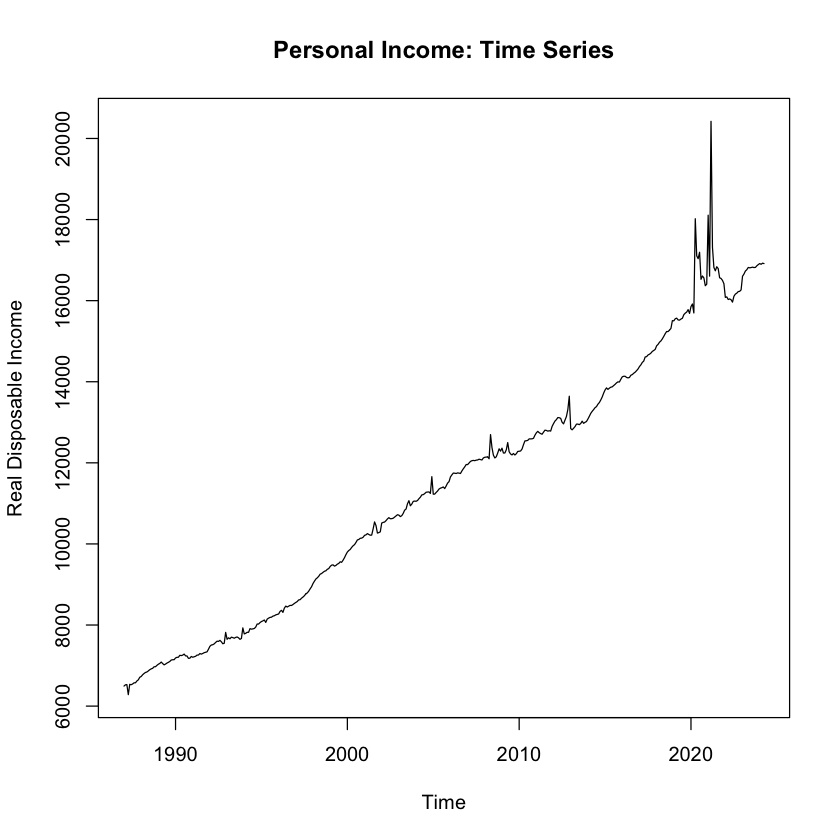

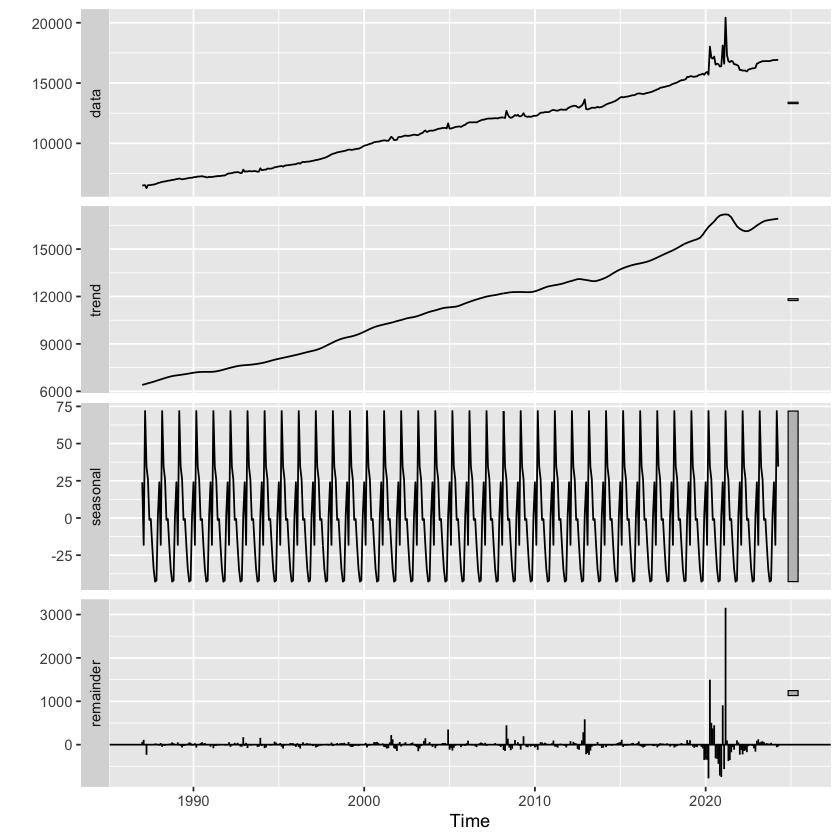

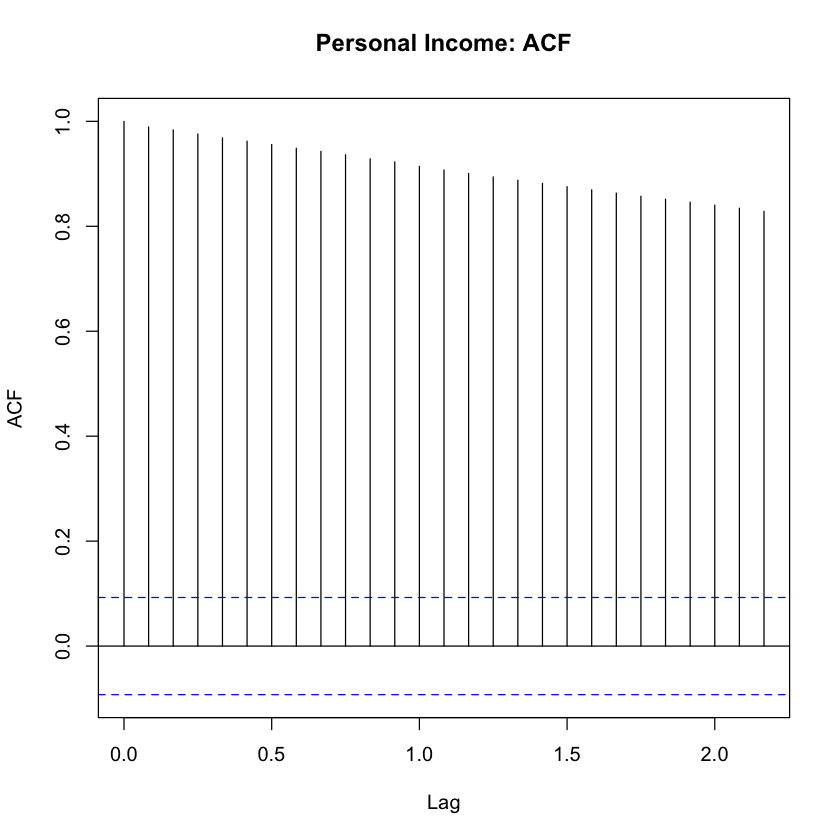

In [4]:
# Time Series, Decomposition & ACF Plots
plot(ts_income, main = "Personal Income: Time Series", ylab = "Real Disposable Income")
decomposed_income = stl(ts_income, s.window = "periodic")
autoplot(decomposed_income)
acf(ts_income, main = "Personal Income: ACF")

In [5]:
# Stationarity & Autocorrelation Tests: Income (Level)
print(adf.test(ts_income))                       # Null: non-stationary
print(kpss.test(ts_income))                      # Null: stationary
print(Box.test(ts_income, type = "Ljung-Box"))   # Null: no autocorrelation


	Augmented Dickey-Fuller Test

data:  ts_income
Dickey-Fuller = -2.6625, Lag order = 7, p-value = 0.2977
alternative hypothesis: stationary



Warning message in kpss.test(ts_income):
“p-value smaller than printed p-value”



	KPSS Test for Level Stationarity

data:  ts_income
KPSS Level = 7.4417, Truncation lag parameter = 5, p-value = 0.01




	Box-Ljung test

data:  ts_income
X-squared = 441.49, df = 1, p-value < 2.2e-16



In [6]:
# First-Order Differencing
ts_income_diff = diff(ts_income, differences = 1)

print(adf.test(ts_income_diff))
print(kpss.test(ts_income_diff))
print(Box.test(ts_income_diff, type = "Ljung-Box"))

Warning message in adf.test(ts_income_diff):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  ts_income_diff
Dickey-Fuller = -11.362, Lag order = 7, p-value = 0.01
alternative hypothesis: stationary



Warning message in kpss.test(ts_income_diff):
“p-value greater than printed p-value”



	KPSS Test for Level Stationarity

data:  ts_income_diff
KPSS Level = 0.029236, Truncation lag parameter = 5, p-value = 0.1




	Box-Ljung test

data:  ts_income_diff
X-squared = 137.23, df = 1, p-value < 2.2e-16



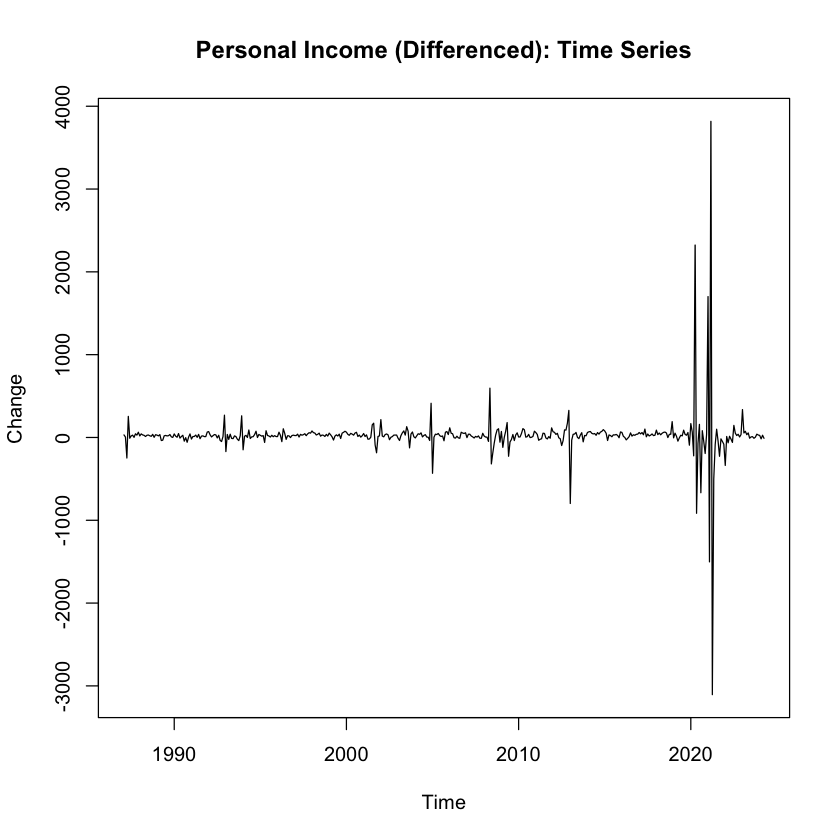

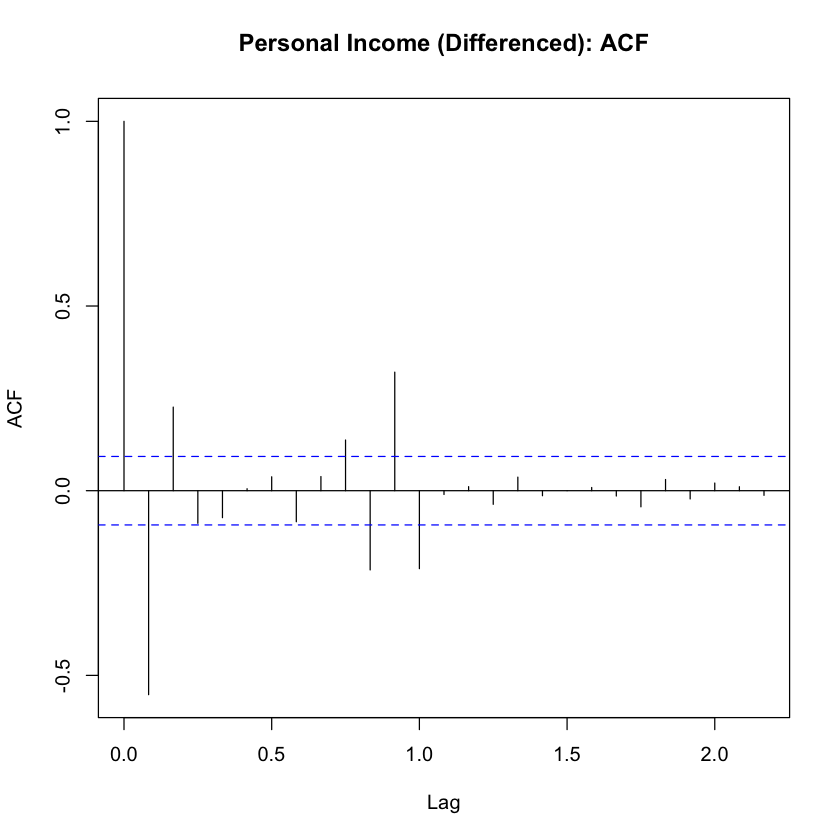

In [7]:
# Differenced Series: Time Series & ACF Plots
plot(ts_income_diff, main = "Personal Income (Differenced): Time Series", ylab = "Change")
acf(ts_income_diff, main = "Personal Income (Differenced): ACF")

In [8]:
# Trend-Only vs. Trend + Seasonality
time_index = 1:length(ts_income)
seasonality = cycle(ts_income)

trend_only_model = lm(ts_income ~ time_index)
full_model = lm(ts_income ~ time_index + as.factor(seasonality))

summary(trend_only_model)
summary(full_model)

# Incremental R-Squared from Adding Seasonality
round(summary(full_model)$r.squared - summary(trend_only_model)$r.squared, 6)


Call:
lm(formula = ts_income ~ time_index)

Residuals:
   Min     1Q Median     3Q    Max 
-778.6 -271.8  -12.1  167.0 4526.1 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 5981.3109    40.0340   149.4   <2e-16 ***
time_index    24.1245     0.1545   156.1   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 423 on 446 degrees of freedom
Multiple R-squared:  0.982,	Adjusted R-squared:  0.982 
F-statistic: 2.438e+04 on 1 and 446 DF,  p-value: < 2.2e-16



Call:
lm(formula = ts_income ~ time_index + as.factor(seasonality))

Residuals:
   Min     1Q Median     3Q    Max 
-805.4 -265.3  -16.6  167.2 4449.0 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)              6007.1082    77.4532  77.558   <2e-16 ***
time_index                 24.1259     0.1559 154.765   <2e-16 ***
as.factor(seasonality)2   -40.6285    97.8832  -0.415    0.678    
as.factor(seasonality)3    50.7587    97.8836   0.519    0.604    
as.factor(seasonality)4    13.8986    97.8842   0.142    0.887    
as.factor(seasonality)5     3.7460    98.5427   0.038    0.970    
as.factor(seasonality)6   -24.6448    98.5423  -0.250    0.803    
as.factor(seasonality)7   -25.1112    98.5422  -0.255    0.799    
as.factor(seasonality)8   -45.6885    98.5423  -0.464    0.643    
as.factor(seasonality)9   -64.3414    98.5427  -0.653    0.514    
as.factor(seasonality)10  -74.9187    98.5433  -0.760    0.448    
as.factor(seasonality)11  -7

[1] 0.000136

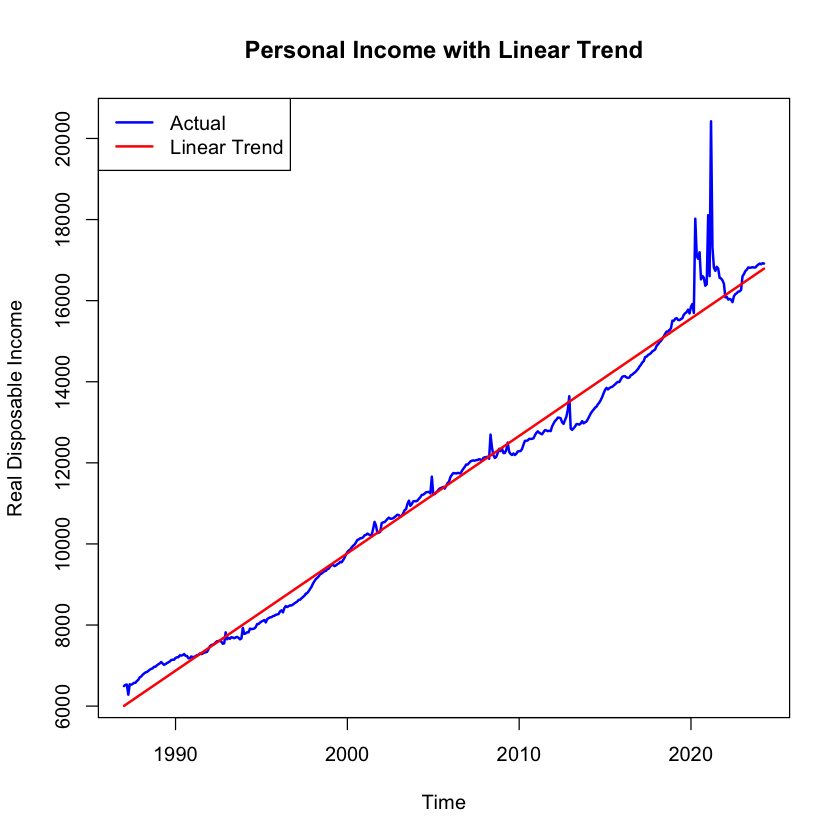

In [9]:
# Linear Trend Overlay
trend_line = predict(trend_only_model)

plot(ts_income, main = "Personal Income with Linear Trend", ylab = "Real Disposable Income",
     col = "blue", lwd = 2)
lines(ts(trend_line, start = c(1987, 1), frequency = 12), col = "red", lwd = 2)
legend("topleft", legend = c("Actual", "Linear Trend"), col = c("blue", "red"), lwd = 2)

**Findings:**

- The income level series is non-stationary (ADF fails to reject, KPSS rejects, Ljung-Box confirms strong autocorrelation); first-differencing achieves stationarity on all three tests
- Trend alone already explains the overwhelming majority of variation in the level series
- Adding monthly seasonal indicators to the trend model produces only a small incremental improvement in R-squared: predictability in this series is dominated by its long-run trend, not seasonal structure
- This matters for the VAR analysis below: it confirms differencing (rather than seasonal adjustment) is the right way to induce stationarity before modeling

---

## Personal Income and Home Prices: A VAR Analysis

**Question:** Is there a relationship between personal income and home prices, and if so, in which direction?

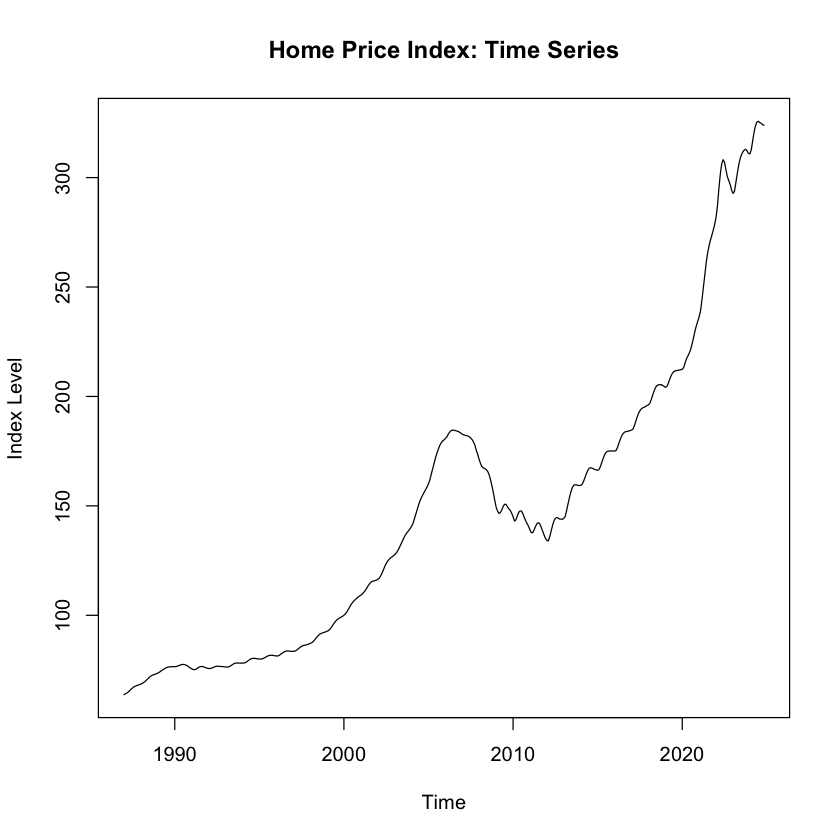

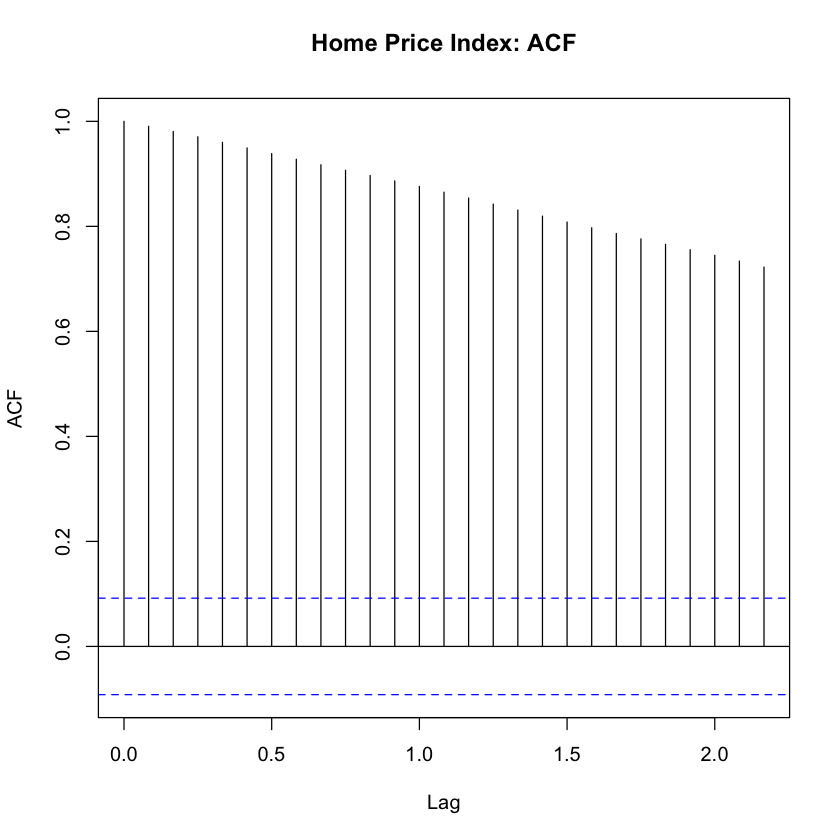

In [10]:
# Time Series & ACF Plots: Home Price Index
plot(ts_hpi, main = "Home Price Index: Time Series", ylab = "Index Level")
acf(ts_hpi, main = "Home Price Index: ACF")

In [11]:
# Stationarity & Autocorrelation Tests: Home Price Index (Level)
print(adf.test(ts_hpi))
print(kpss.test(ts_hpi))
print(Box.test(ts_hpi, type = "Ljung-Box"))


	Augmented Dickey-Fuller Test

data:  ts_hpi
Dickey-Fuller = -0.83233, Lag order = 7, p-value = 0.9586
alternative hypothesis: stationary



Warning message in kpss.test(ts_hpi):
“p-value smaller than printed p-value”



	KPSS Test for Level Stationarity

data:  ts_hpi
KPSS Level = 6.3907, Truncation lag parameter = 5, p-value = 0.01




	Box-Ljung test

data:  ts_hpi
X-squared = 449.42, df = 1, p-value < 2.2e-16



In [12]:
# Second-Order Differencing
ts_hpi_diff = diff(ts_hpi, differences = 2)

print(adf.test(ts_hpi_diff))
print(kpss.test(ts_hpi_diff))
print(Box.test(ts_hpi_diff, type = "Ljung-Box"))

Warning message in adf.test(ts_hpi_diff):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  ts_hpi_diff
Dickey-Fuller = -15.7, Lag order = 7, p-value = 0.01
alternative hypothesis: stationary



Warning message in kpss.test(ts_hpi_diff):
“p-value greater than printed p-value”



	KPSS Test for Level Stationarity

data:  ts_hpi_diff
KPSS Level = 0.0088777, Truncation lag parameter = 5, p-value = 0.1




	Box-Ljung test

data:  ts_hpi_diff
X-squared = 157.53, df = 1, p-value < 2.2e-16



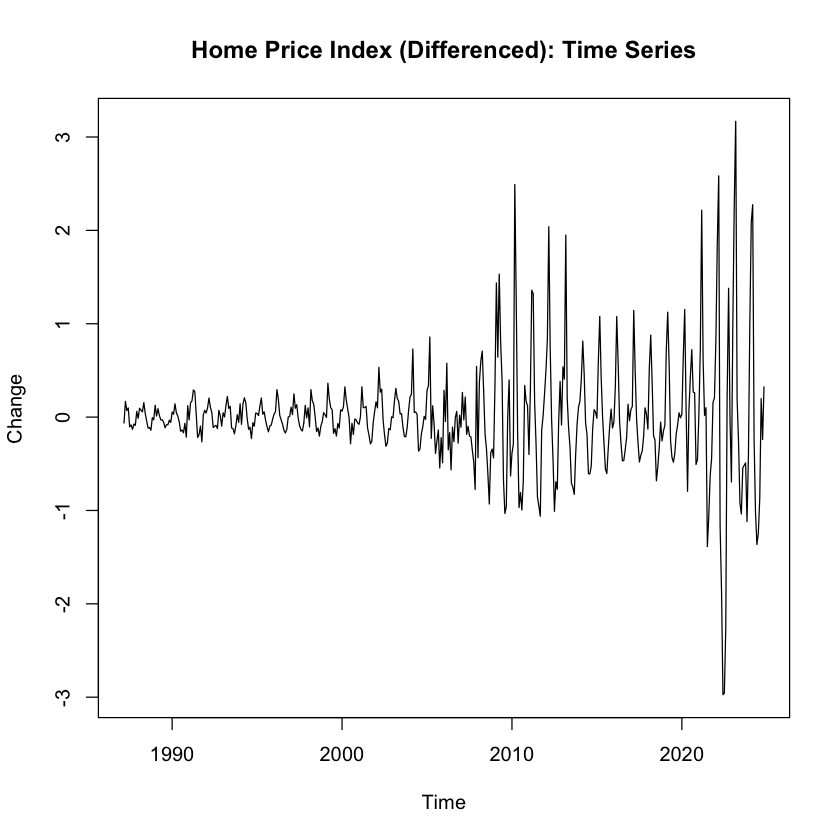

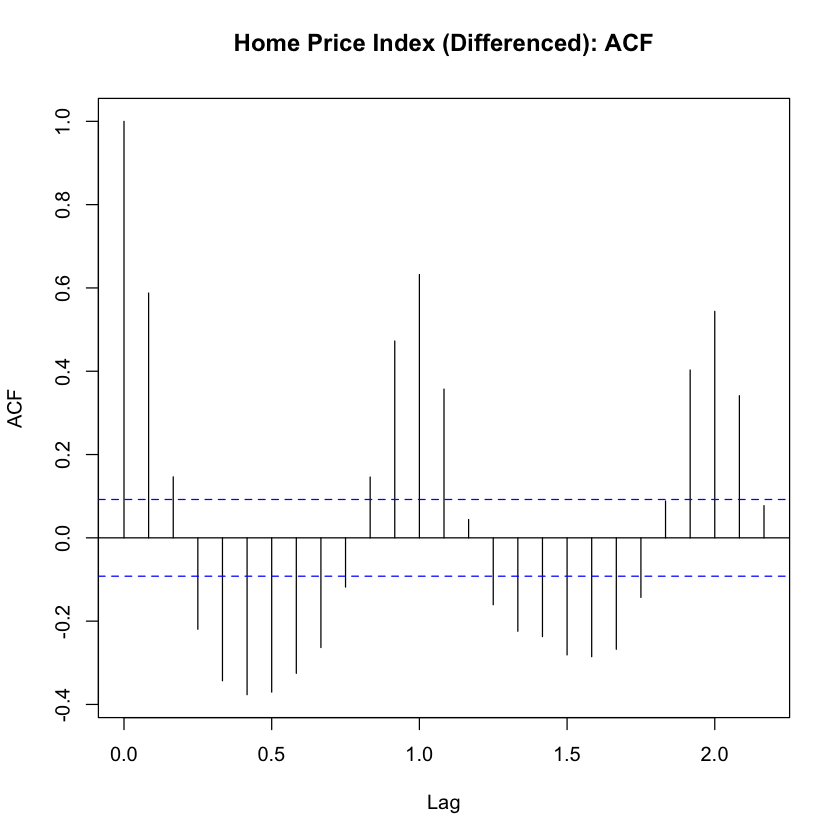

In [13]:
# Differenced Series: Time Series & ACF Plots
plot(ts_hpi_diff, main = "Home Price Index (Differenced): Time Series", ylab = "Change")
acf(ts_hpi_diff, main = "Home Price Index (Differenced): ACF")

### Fitting the VAR Model

Both series are non-stationary in levels and are brought to stationarity by differencing (first-order for income, second-order for the home price index). The two differenced series are combined into a single Vector Autoregression, with lag order chosen by AIC.

In [14]:
# Combine Differenced Series & Select Lag Order (AIC)
ts_data = ts.intersect(ts_income_diff, ts_hpi_diff)  # align differing series lengths from differencing orders 1 vs. 2
lag_selection = VARselect(ts_data, lag.max = 12, type = "const")
optimal_lag = lag_selection$selection["AIC(n)"]

print(lag_selection$selection)

# Fit VAR Model
var_model = VAR(ts_data, p = optimal_lag, type = "const")
summary(var_model)

AIC(n)  HQ(n)  SC(n) FPE(n) 
    12     12     12     12 



VAR Estimation Results:
Endogenous variables: ts_income_diff, ts_hpi_diff 
Deterministic variables: const 
Sample size: 434 
Log Likelihood: -3071.248 
Roots of the characteristic polynomial:
0.9933 0.9933 0.9785 0.9785 0.9356 0.9356 0.933 0.933 0.9133 0.9133 0.9123 0.9123 0.9051 0.9051 0.8846 0.8846 0.8806 0.8806 0.8602 0.8551 0.8551 0.8486 0.8486 0.1928
Call:
VAR(y = ts_data, p = optimal_lag, type = "const")


Estimation results for equation ts_income_diff: 
ts_income_diff = ts_income_diff.l1 + ts_hpi_diff.l1 + ts_income_diff.l2 + ts_hpi_diff.l2 + ts_income_diff.l3 + ts_hpi_diff.l3 + ts_income_diff.l4 + ts_hpi_diff.l4 + ts_income_diff.l5 + ts_hpi_diff.l5 + ts_income_diff.l6 + ts_hpi_diff.l6 + ts_income_diff.l7 + ts_hpi_diff.l7 + ts_income_diff.l8 + ts_hpi_diff.l8 + ts_income_diff.l9 + ts_hpi_diff.l9 + ts_income_diff.l10 + ts_hpi_diff.l10 + ts_income_diff.l11 + ts_hpi_diff.l11 + ts_income_diff.l12 + ts_hpi_diff.l12 + const 

                    Estimate Std. Error t value Pr(>|t|)   

In [15]:
# Serial Correlation in Residuals (Portmanteau Test)
serial_test = serial.test(var_model, type = "PT.asymptotic")
print(serial_test)


	Portmanteau Test (asymptotic)

data:  Residuals of VAR object var_model
Chi-squared = 98.175, df = 16, p-value = 7.605e-14



$serial

	Portmanteau Test (asymptotic)

data:  Residuals of VAR object var_model
Chi-squared = 98.175, df = 16, p-value = 7.605e-14



**Note:** The Portmanteau test rejects the null of no residual autocorrelation (p < 2.2e-16). The VAR is not capturing all of the dependence in the data — additional lags or omitted exogenous variables likely remain. The Granger-causality results below should be read as evidence of a real, directional relationship, not as a fully specified forecasting model.

In [16]:
# Granger Causality Tests
granger_income = causality(var_model, cause = "ts_income_diff")
granger_hpi = causality(var_model, cause = "ts_hpi_diff")

print(granger_income)
print(granger_hpi)

$Granger

	Granger causality H0: ts_income_diff do not Granger-cause ts_hpi_diff

data:  VAR object var_model
F-Test = 12.718, df1 = 12, df2 = 818, p-value < 2.2e-16


$Instant

	H0: No instantaneous causality between: ts_income_diff and ts_hpi_diff

data:  VAR object var_model
Chi-squared = 0.51815, df = 1, p-value = 0.4716




$Granger

	Granger causality H0: ts_hpi_diff do not Granger-cause ts_income_diff

data:  VAR object var_model
F-Test = 2.1201, df1 = 12, df2 = 818, p-value = 0.01387


$Instant

	H0: No instantaneous causality between: ts_hpi_diff and ts_income_diff

data:  VAR object var_model
Chi-squared = 0.51815, df = 1, p-value = 0.4716




In [17]:
# Additional Residual Diagnostics
print(normality.test(var_model))  # Jarque-Bera: residual normality
print(arch.test(var_model))       # White's test: residual heteroscedasticity

$JB

	JB-Test (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 53790, df = 4, p-value < 2.2e-16


$Skewness

	Skewness only (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 1273.6, df = 2, p-value < 2.2e-16


$Kurtosis

	Kurtosis only (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 52517, df = 2, p-value < 2.2e-16




$jb.mul
$jb.mul$JB

	JB-Test (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 53790, df = 4, p-value < 2.2e-16


$jb.mul$Skewness

	Skewness only (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 1273.6, df = 2, p-value < 2.2e-16


$jb.mul$Kurtosis

	Kurtosis only (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 52517, df = 2, p-value < 2.2e-16





	ARCH (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 180.47, df = 45, p-value < 2.2e-16



$arch.mul

	ARCH (multivariate)

data:  Residuals of VAR object var_model
Chi-squared = 180.47, df = 45, p-value < 2.2e-16



**Findings:**

- Income Granger-causes home prices: past income changes carry statistically significant predictive information for future home price changes
- Home prices Granger-cause income as well, but the effect is weaker
- No evidence of instantaneous causality between the two series in the same period
- Residual diagnostics (Portmanteau, normality, ARCH tests) indicate the fitted VAR leaves some structure unexplained, so these results describe a genuine directional relationship, not a complete predictive model

---

## Conclusions

- **Income's own predictability** is driven almost entirely by its long-run trend; seasonal structure adds little beyond that trend, once the series is properly differenced to remove non-stationarity
- **Income and home prices are dynamically related**, with income changes leading home price changes more strongly than the reverse — consistent with disposable income functioning as a demand-side driver of housing prices rather than the other way around
- The VAR captures a real relationship but not the full dependence structure in the data (per the residual diagnostics); a model with additional lags, or exogenous variables such as mortgage rates or housing supply, would likely improve on it
- Practically: income trends are a leading indicator worth monitoring for anticipated shifts in home prices, though the reverse channel (home prices influencing income) is real but comparatively modest